# 05 Cohorts, survival and customer lifetime value - Part A: do customers from different channels re-order differently?
**Question:** which acquisition channels bring customers who come back, and how fast?

Data: own-website ledger extract, stage 2 (weeks 1-104). *Prakriti Foods is fictional; all data is synthetic.*

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, datetime as dt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
c = pd.read_csv('../data/stage2/customers.csv', parse_dates=['first_order_date']); o = pd.read_csv('../data/stage2/orders.csv', parse_dates=['date'])
END = pd.Timestamp('2024-10-07') + pd.Timedelta(weeks=104)       # end of the data
o = o.sort_values(['customer_id','date']); o['n'] = o.groupby('customer_id').cumcount()
first = o[o.n==0].set_index('customer_id'); second = o[o.n==1].set_index('customer_id')
d = c.set_index('customer_id').join(first[['gross_value','discount']]).join(second['date'].rename('second_date'))
d['event'] = d.second_date.notna().astype(int)
d['weeks'] = ((d.second_date.fillna(END) - d.first_order_date).dt.days / 7).clip(lower=1/7)
d['disc_pct'] = d.discount / d.gross_value
print(len(d), 'customers;', f'{d.event.mean():.0%} placed a second order by the end of the data (the rest are censored)')
d.groupby('acquisition_channel').agg(customers=('event','size'), reordered=('event','mean'), median_first_value=('gross_value','median'), mean_discount=('disc_pct','mean')).round(3)

27865 customers; 49% placed a second order by the end of the data (the rest are censored)


,customers,reordered,median_first_value,mean_discount
acquisition_channel,,,,
Google_Search,1219,0.462,633.520,0.015
Influencers,1287,0.523,591.130,0.016
Meta,2935,0.458,646.780,0.015
Organic,20092,0.503,587.245,0.015
Trade_Promo,915,0.358,655.680,0.201
YouTube,1417,0.487,603.750,0.014


## 1. Kaplan-Meier: share still waiting for a second order, by weeks since first order
Event = second order. Customers with no second order by the end of the data are censored (we only know they had not re-ordered yet).

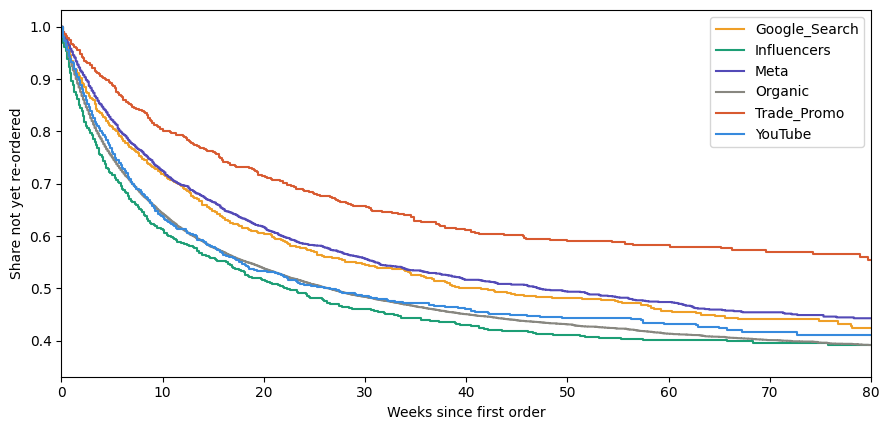

,re-ordered by 13 wks,re-ordered by 26 wks,re-ordered by 52 wks
Influencers,0.421,0.523,0.592
YouTube,0.399,0.499,0.556
Organic,0.400,0.498,0.573
Google_Search,0.325,0.440,0.520
Meta,0.314,0.422,0.511
Trade_Promo,0.224,0.323,0.409


In [2]:
col = {'Influencers':'#1D9E75','YouTube':'#378ADD','Organic':'#888780','Meta':'#534AB7','Google_Search':'#EF9F27','Trade_Promo':'#D85A30'}
fig, ax = plt.subplots(figsize=(9,4.4)); km_tab = {}
for ch, g in d.groupby('acquisition_channel'):
    k = KaplanMeierFitter().fit(g.weeks, g.event, label=ch); k.plot_survival_function(ax=ax, ci_show=False, color=col[ch])
    km_tab[ch] = {'re-ordered by 13 wks': 1-float(k.predict(13)), 're-ordered by 26 wks': 1-float(k.predict(26)), 're-ordered by 52 wks': 1-float(k.predict(52))}
ax.set_xlabel('Weeks since first order'); ax.set_ylabel('Share not yet re-ordered'); ax.set_xlim(0, 80); plt.tight_layout(); plt.show()
pd.DataFrame(km_tab).T.round(3).sort_values('re-ordered by 26 wks', ascending=False)

## 2. Do the curves differ? Log-rank test

In [3]:
lr = multivariate_logrank_test(d.weeks, d.acquisition_channel, d.event)
print(f'Multivariate log-rank: chi-square {lr.test_statistic:.1f}, p = {lr.p_value:.2g}  (curves differ: {lr.p_value<0.05})')

Multivariate log-rank: chi-square 162.6, p = 2.7e-33  (curves differ: True)


## 3. Cox model: do channels differ after controlling for first-order value and discount?
Hazard ratio above 1 = re-orders sooner than the reference (Organic).

In [4]:
X = pd.get_dummies(d[['acquisition_channel']], drop_first=False).astype(float).drop(columns='acquisition_channel_Organic')
X['log_first_value'] = np.log(d.gross_value); X['disc_pct'] = d.disc_pct
X['weeks'] = d.weeks; X['event'] = d.event
cph = CoxPHFitter().fit(X, 'weeks', 'event')
s = cph.summary[['exp(coef)','exp(coef) lower 95%','exp(coef) upper 95%','p']].round(3); s.columns = ['hazard_ratio','low95','high95','p']; s

,hazard_ratio,low95,high95,p
covariate,,,,
acquisition_channel_Google_Search,0.846,0.777,0.921,0.000
acquisition_channel_Influencers,1.070,0.990,1.157,0.089
acquisition_channel_Meta,0.805,0.761,0.853,0.000
acquisition_channel_Trade_Promo,0.668,0.561,0.796,0.000
acquisition_channel_YouTube,0.978,0.905,1.056,0.566
log_first_value,0.979,0.926,1.035,0.452
disc_pct,0.469,0.226,0.971,0.041


## Answer

In [5]:
order = pd.DataFrame(km_tab).T['re-ordered by 26 wks'].sort_values(ascending=False)
print('Share re-ordering within 26 weeks, best to worst:', order.round(2).to_dict())
print('Log-rank p:', f'{lr.p_value:.2g}', '| Channels re-ordering significantly sooner than Organic (Cox, p<0.05):', [i.replace('acquisition_channel_','') for i,r in s.iterrows() if i.startswith('acq') and r.p<0.05 and r.hazard_ratio>1])
print('Channels re-ordering significantly later than Organic:', [i.replace('acquisition_channel_','') for i,r in s.iterrows() if i.startswith('acq') and r.p<0.05 and r.hazard_ratio<1])

Share re-ordering within 26 weeks, best to worst: {'Influencers': 0.52, 'YouTube': 0.5, 'Organic': 0.5, 'Google_Search': 0.44, 'Meta': 0.42, 'Trade_Promo': 0.32}
Log-rank p: 2.7e-33 | Channels re-ordering significantly sooner than Organic (Cox, p<0.05): []
Channels re-ordering significantly later than Organic: ['Google_Search', 'Meta', 'Trade_Promo']


---
# Part B: customer lifetime value, CAC and CLV-adjusted ROI
**Question:** which channels bring customers worth more over time, and does that change the channel ranking?

**Method:** BG/NBD (purchase timing and drop-out) and Gamma-Gamma (spend per order) from PyMC-Marketing 1.1, fitted separately by acquisition channel (`clv_fit.py`, `clv_run.py`). MAP estimates; the 90% intervals come from 10 customer-level bootstrap refits per channel (a small number, so treat the intervals as rough). CLV here is **future contribution margin per customer** after the first order, 1% monthly discount, in Rs.

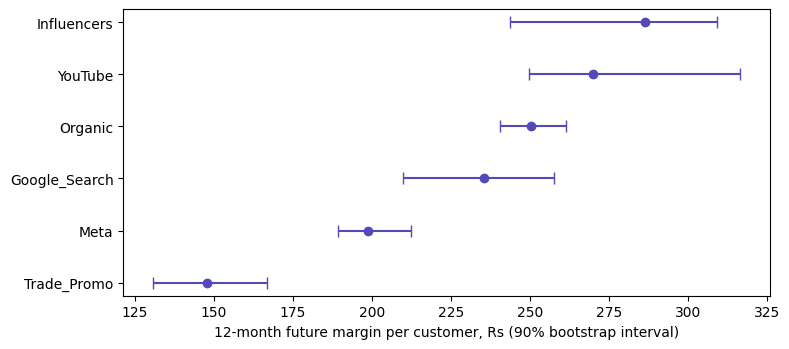

,customers,first_order_margin,clv12,clv12_p5,clv12_p95,clv24,LTV12,LTV24
channel,,,,,,,,
Influencers,1287,253.0,286.0,244.0,309.0,441.0,539.0,694.0
YouTube,1417,255.0,270.0,250.0,317.0,414.0,525.0,669.0
Organic,20092,251.0,250.0,240.0,261.0,382.0,502.0,633.0
Google_Search,1219,270.0,236.0,210.0,258.0,370.0,505.0,640.0
Meta,2935,275.0,199.0,189.0,212.0,308.0,474.0,582.0
Trade_Promo,915,225.0,148.0,131.0,167.0,233.0,372.0,458.0


In [6]:
clv = pd.read_csv('../model/clv_by_channel.csv', index_col=0)
fo = o[o.n==0].merge(c[['customer_id','acquisition_channel']], on='customer_id').groupby('acquisition_channel').contribution.mean().rename('first_order_margin')
t = clv.join(fo); t['LTV12'] = t.first_order_margin + t.clv12; t['LTV24'] = t.first_order_margin + t.clv24
fig, ax = plt.subplots(figsize=(8,3.6)); tt = t.sort_values('clv12'); yy = np.arange(len(tt))
ax.errorbar(tt.clv12, yy, xerr=[tt.clv12-tt.clv12_p5, tt.clv12_p95-tt.clv12], fmt='o', color='#534AB7', capsize=4); ax.set_yticks(yy); ax.set_yticklabels(tt.index)
ax.set_xlabel('12-month future margin per customer, Rs (90% bootstrap interval)'); plt.tight_layout(); plt.show()
t[['customers','first_order_margin','clv12','clv12_p5','clv12_p95','clv24','LTV12','LTV24']].round(0).sort_values('clv12', ascending=False)

## CAC, CAC:LTV and payback
Gross CAC = a channel's paid spend / the website customers attributed to it (the ledger is a sample, scaled up by its share of weekly new customers). **This overstates true CAC**: the same spend also lifts quick-commerce and marketplace sales that never appear as website customers. Use it to rank channels, not to compare with the Rs 800-1,200 benchmark.

In [7]:
w = pd.read_csv('../data/stage2/weekly_geo.csv'); SP = {'Meta':'spend_Meta_lakh','Google_Search':'spend_Google_Search_lakh','YouTube':'spend_YouTube_lakh','Influencers':'spend_Influencers_lakh','Trade_Promo':'spend_Trade_Promo_lakh'}
frac = len(c)/w.new_customers.sum()
cac = pd.Series({k: w[v].sum()*1e5/(((c.acquisition_channel==k).sum())/frac) for k,v in SP.items()}, name='gross_CAC')
# empirical payback: cumulative margin per customer by months since first order (customers acquired in weeks 1-52, so 12+ months of follow-up exist)
oo = o.merge(c[['customer_id','acquisition_channel','acquisition_week']], on='customer_id'); oo = oo[oo.acquisition_week <= 52]
fd = oo.groupby('customer_id').date.transform('min'); oo['m'] = ((oo.date - fd).dt.days/30.4).astype(int)
ncust = oo.drop_duplicates('customer_id').groupby('acquisition_channel').size()
cum = oo.groupby(['acquisition_channel','m']).contribution.sum().unstack(fill_value=0).cumsum(axis=1).div(ncust, axis=0)
def payback(ch):
    if ch not in cac.index: return np.nan
    hit = cum.loc[ch][cum.loc[ch] >= cac[ch]]
    return float(hit.index[0]) if len(hit) else np.inf
res = t.join(cac); res['CAC_to_LTV12'] = res.gross_CAC / res.LTV12; res['payback_months'] = [payback(i) for i in res.index]
res.loc[res.index!='Organic', ['gross_CAC','LTV12','LTV24','CAC_to_LTV12','payback_months']].round(2).sort_values('CAC_to_LTV12')

,gross_CAC,LTV12,LTV24,CAC_to_LTV12,payback_months
channel,,,,,
Influencers,2782.52,539.46,693.93,5.16,inf
YouTube,2957.93,524.97,669.07,5.63,inf
Meta,3317.35,473.59,582.43,7.00,inf
Google_Search,4512.03,505.38,639.78,8.93,inf
Trade_Promo,5292.12,372.46,457.78,14.21,inf


## CLV-adjusted ROI vs short-term ROI
CLV uplift factor = (first-order margin + 12-month future margin) / first-order margin: how much more lifetime margin a channel's customers bring than the first order alone. CLV-adjusted ROI = MMM v2 ROI x uplift factor. This assumes the customers a channel brings through quick-commerce and marketplaces behave like its website customers (an assumption, not a finding). Quick-commerce ads have no website customers, so they get a factor of 1 (no adjustment), which is conservative for them.

In [8]:
roi = pd.read_csv('../model/mmm_v2_roi_estimates.csv', index_col=0)
u = (res.LTV12/res.first_order_margin).reindex(roi.index).fillna(1.0)
adj = pd.DataFrame({'ROI_short_term': roi.ROI_mean, 'uplift_factor': u, 'ROI_CLV_adjusted': roi.ROI_mean*u})
adj['rank_short'] = adj.ROI_short_term.rank(ascending=False).astype(int); adj['rank_CLV_adj'] = adj.ROI_CLV_adjusted.rank(ascending=False).astype(int)
adj['rank_change'] = adj.rank_short - adj.rank_CLV_adj; adj.to_csv('../model/clv_adjusted_roi.csv'); adj.round(2).sort_values('rank_CLV_adj')

,ROI_short_term,uplift_factor,ROI_CLV_adjusted,rank_short,rank_CLV_adj,rank_change
Influencers,3.54,2.13,7.55,1,1,0
YouTube,1.79,2.06,3.69,4,2,2
Trade_Promo,2.21,1.66,3.66,2,3,-1
Meta,2.01,1.72,3.47,3,4,-1
Google_Search,1.43,1.87,2.68,5,5,0
QC_Ads,1.39,1.00,1.39,6,6,0


## Answer

In [9]:
best = res.drop(index='Organic').clv12.idxmax(); worst = res.drop(index='Organic').clv12.idxmin()
print(f'Highest 12-month future margin per customer: {best} (Rs {res.loc[best,"clv12"]:.0f}); lowest: {worst} (Rs {res.loc[worst,"clv12"]:.0f}). Ranking by CLV matches the re-order ranking in Part A.')
print('Channels whose ROI rank changes after CLV adjustment:', {i: int(r) for i,r in adj.rank_change.items() if r!=0} or 'none')
print('Gross CAC exceeds 12-month LTV for:', [i for i,r in res.drop(index='Organic').iterrows() if r.CAC_to_LTV12>1])

Highest 12-month future margin per customer: Influencers (Rs 286); lowest: Trade_Promo (Rs 148). Ranking by CLV matches the re-order ranking in Part A.
Channels whose ROI rank changes after CLV adjustment: {'Meta': -1, 'YouTube': 2, 'Trade_Promo': -1}
Gross CAC exceeds 12-month LTV for: ['Influencers', 'YouTube', 'Google_Search', 'Meta', 'Trade_Promo']


**Interpretation and a flag.** (1) Customers from influencers and YouTube are worth the most over 12 and 24 months; trade-promotion customers the least (about half of influencers'). Meta and Google Search sit in between. (2) After the CLV adjustment YouTube moves up two places, and trade promotions and Meta each drop one. Influencers lead on both measures. Quick-commerce ads are last on both, but only because they were given no CLV adjustment. (3) **The CAC columns are not credible as absolute numbers.** Gross CAC (Rs 2,800 to 5,300) is 5-14 times the 12-month LTV and nothing pays back within 24 months. The cause is the allocation: a channel's whole spend is divided by its website customers only. Even the brief's own benchmark CAC of Rs 800-1,200 would not pay back, since a typical customer is worth about Rs 370-540 of margin over 12 months (Rs 250-275 per order at 35-45% margin and about 2 orders in the first year). The brief's CAC benchmark and its margin and repeat assumptions do not fit together. The ranking and the CLV-adjusted ROI use ratios between channels, so they are not affected, but the CAC:CLV and payback figures should be read as relative, not absolute.